# Phase 1 — Data Quality

Questions to answer:
- How many missing values, and are they random or concentrated?
- Any duplicated timestamps?
- Any impossible values (negative power, voltage spikes)?

Deliverables: missing-value heatmap, time-gap analysis, sensor reliability report.

In [3]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_raw, save_processed
from src.data.quality import missing_value_report, time_gap_report, impossible_value_report, duplicate_timestamp_report

In [4]:
df = load_raw()
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
missing_value_report(df)

,missing_count,missing_pct
Global_active_power,25979,1.252
Global_reactive_power,25979,1.252
Voltage,25979,1.252
Global_intensity,25979,1.252
Sub_metering_1,25979,1.252
Sub_metering_2,25979,1.252
Sub_metering_3,25979,1.252


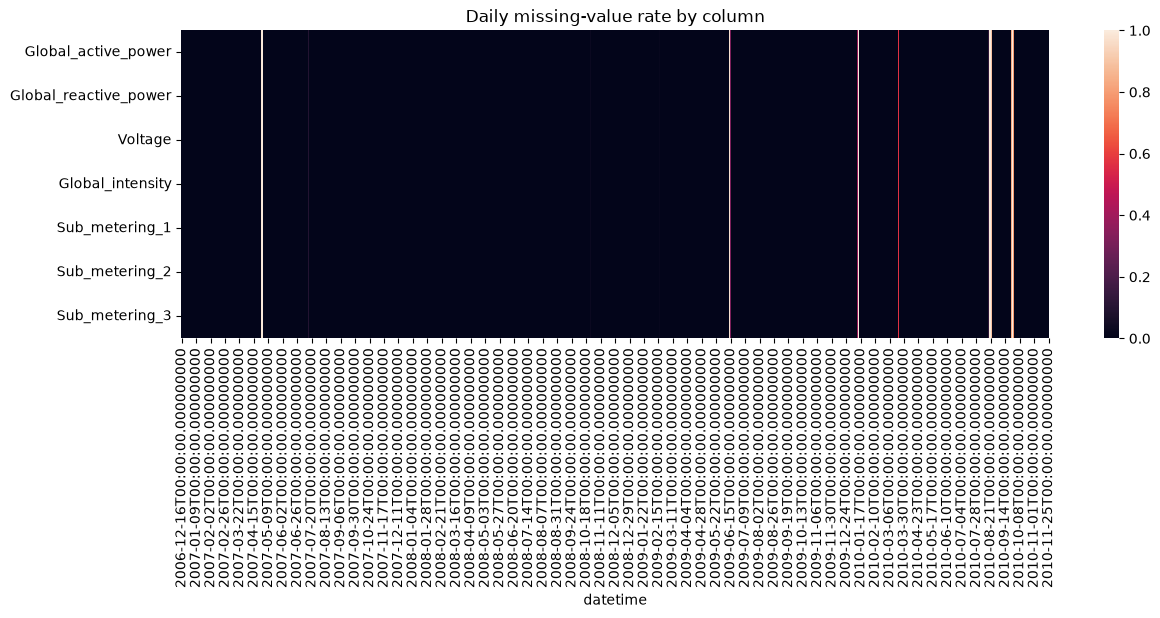

In [6]:
# Missing-value heatmap (downsample for plotting)
import seaborn as sns
sample = df.isna().resample('1D').mean()
plt.figure(figsize=(14, 4))
sns.heatmap(sample.T, cbar=True)
plt.title('Daily missing-value rate by column')
plt.show()

In [7]:
gaps = time_gap_report(df)
gaps.sort_values('n_missing', ascending=False).head(20)

,gap_start,gap_end,n_missing


In [8]:
impossible_value_report(df)

{'negative_active_power': 0,
 'voltage_out_of_range': 0,
 'negative_intensity': 0}

In [9]:
duplicate_timestamp_report(df)

0

## Write-up

Summarize: missing-value patterns, largest gaps and likely cause (sensor outage vs vacation), any impossible values found, and how you'll handle them (drop / interpolate / flag).

In [10]:
df_clean = df.copy()
# Document your missing-value handling decision here, e.g.:
# df_clean['Global_active_power'] = df_clean['Global_active_power'].ffill(limit=5)

save_processed(df_clean)
print('Saved to:', end=' ')
from src.data.loader import PROCESSED_PATH
print(PROCESSED_PATH, PROCESSED_PATH.exists())

Saved to: /Users/apple/Documents/Projects/energy-demand-forecasting/data/processed/household_power_consumption.parquet True
